#### Cell 1: Import Library

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#### Cell 2: Kelas Inti Probabilistic Neural Network (PNN)

In [2]:
class ProbabilisticNeuralNetwork:
    def __init__(self, sigma=1.0):
        self.sigma = sigma
        self.X_train = None
        self.y_train = None
        self.classes_ = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        self.classes_ = np.unique(self.y_train)
        return self

    def predict_proba(self, X):
        X = np.array(X)
        probabilities = np.zeros((X.shape[0], len(self.classes_)))

        for i, cls in enumerate(self.classes_):
            X_cls = self.X_train[self.y_train == cls]

            for j, x_test in enumerate(X):
                distances = np.linalg.norm(X_cls - x_test, axis=1)
                kernels = np.exp(-(distances ** 2) / (2 * self.sigma ** 2))
                probabilities[j, i] = np.sum(kernels)

        row_sums = probabilities.sum(axis=1, keepdims=True)
        probabilities = np.divide(probabilities, row_sums, out=np.zeros_like(probabilities), where=row_sums!=0)

        return probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

#### Cell 3: Memuat Data dan Pemilihan Fitur

In [3]:
FILE_PATH = '../../dataset/ANN/dataset_kelulusan_mahasiswa.csv'

df = pd.read_csv(FILE_PATH)
print(f"Dataset Sendiri berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom.")

selected_features = [
    'Tugas_1',
    'Tugas_2',
    'Tugas_3',
    'UTS',
    'UAS'
]

df['Target'] = df['Status'].map({
    'Lulus': 0,
    'Tidak_Lulus': 1
})

print("\nDistribusi Target:")
print(df['Target'].value_counts())

X = df[selected_features]
y = df['Target']

TEST_SIZE = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

print(f"\nData berhasil dibagi: {X_train.shape[0]} baris untuk training, {X_test.shape[0]} baris testing.")
print("Fitur yang digunakan:", selected_features)

Dataset Sendiri berhasil dimuat: 600 baris, 12 kolom.

Distribusi Target:
Target
0    320
1    280
Name: count, dtype: int64

Data berhasil dibagi: 480 baris untuk training, 120 baris testing.
Fitur yang digunakan: ['Tugas_1', 'Tugas_2', 'Tugas_3', 'UTS', 'UAS']


#### Cell 4: Mencari Sigma Terbaik dengan 5-Fold CV (Anti Data-Leakage)

In [4]:
print("Memulai pencarian sigma terbaik menggunakan 5-Fold Cross-Validation...\n")

daftar_sigma = np.logspace(-2, 1, 20)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_train_np = np.array(X_train) 
y_train_np = np.array(y_train)
rata_rata_akurasi = {}

for s in daftar_sigma:
    fold_akurasi = []
    
    for train_idx, val_idx in cv.split(X_train_np, y_train_np):
        X_fold_train, X_fold_val = X_train_np[train_idx], X_train_np[val_idx]
        y_fold_train, y_fold_val = y_train_np[train_idx], y_train_np[val_idx]
        
        # Standarisasi (Scaler) dilakukan di dalam loop agar terhindar dari kebocoran data
        scaler_cv = StandardScaler()
        X_fold_train_scaled = scaler_cv.fit_transform(X_fold_train)
        X_fold_val_scaled = scaler_cv.transform(X_fold_val)
        
        model_cv = ProbabilisticNeuralNetwork(sigma=s)
        model_cv.fit(X_fold_train_scaled, y_fold_train)
        
        y_pred_val = model_cv.predict(X_fold_val_scaled)
        fold_akurasi.append(accuracy_score(y_fold_val, y_pred_val))
        
    rata_rata_akurasi[s] = np.mean(fold_akurasi)

SIGMA_TERBAIK = max(rata_rata_akurasi, key=rata_rata_akurasi.get)

print("-" * 50)
print(f"✅ Ditemukan Sigma Terbaik : {SIGMA_TERBAIK:.4f}")
print(f"✅ Akurasi Validasi (CV)   : {rata_rata_akurasi[SIGMA_TERBAIK] * 100:.2f}%")
print("-" * 50)

Memulai pencarian sigma terbaik menggunakan 5-Fold Cross-Validation...

--------------------------------------------------
✅ Ditemukan Sigma Terbaik : 0.5456
✅ Akurasi Validasi (CV)   : 90.83%
--------------------------------------------------


#### Cell 5: Visualisasi Hyperparameter Tuning

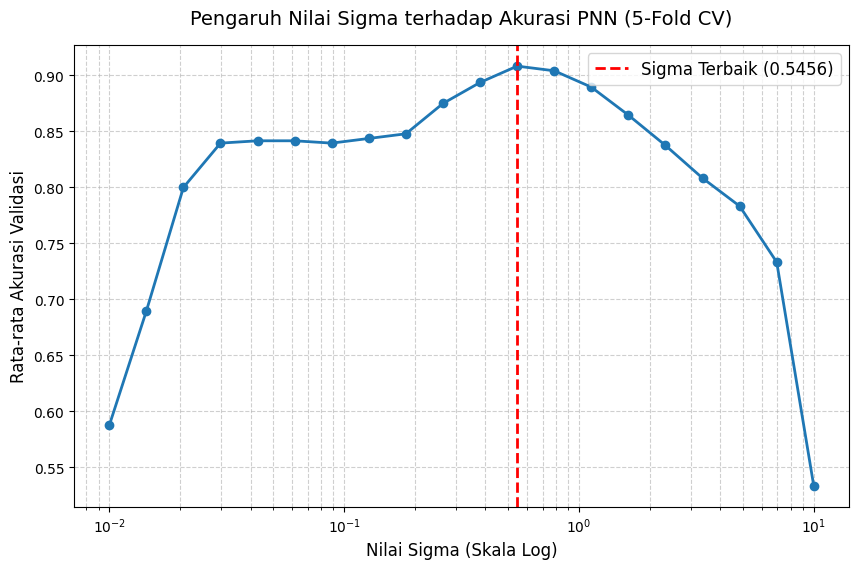

In [5]:
plt.figure(figsize=(10, 6))

sigmas = list(rata_rata_akurasi.keys())
accuracies = list(rata_rata_akurasi.values())

plt.plot(sigmas, accuracies, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.xscale('log')

plt.axvline(x=SIGMA_TERBAIK, color='r', linestyle='--', linewidth=2,
            label=f'Sigma Terbaik ({SIGMA_TERBAIK:.4f})')

plt.title('Pengaruh Nilai Sigma terhadap Akurasi PNN (5-Fold CV)', fontsize=14, pad=15)
plt.xlabel('Nilai Sigma (Skala Log)', fontsize=12)
plt.ylabel('Rata-rata Akurasi Validasi', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

#### Cell 6: Evaluasi Model Akhir pada Data Uji (Testing)

Melatih PNN final dengan Keseluruhan Data Latih (sigma = 0.5456)...

--- HASIL EVALUASI PADA DATA UJI (TESTING) ---
Akurasi Model Akhir : 90.00%

Laporan Klasifikasi:
                 precision    recall  f1-score   support

      Lulus (0)       0.89      0.92      0.91        64
Tidak Lulus (1)       0.91      0.88      0.89        56

       accuracy                           0.90       120
      macro avg       0.90      0.90      0.90       120
   weighted avg       0.90      0.90      0.90       120



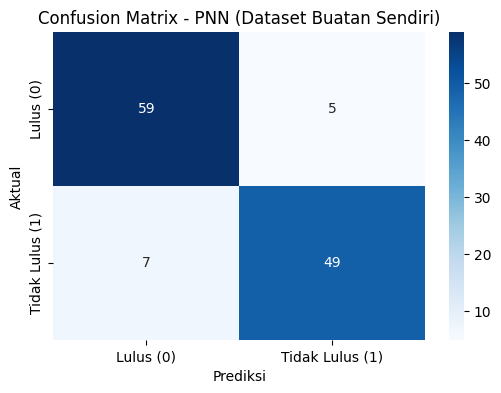

In [6]:
print(f"Melatih PNN final dengan Keseluruhan Data Latih (sigma = {SIGMA_TERBAIK:.4f})...\n")

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

pnn_final = ProbabilisticNeuralNetwork(sigma=SIGMA_TERBAIK)
pnn_final.fit(X_train_scaled, y_train)

y_pred_final = pnn_final.predict(X_test_scaled)

print("--- HASIL EVALUASI PADA DATA UJI (TESTING) ---")
print(f"Akurasi Model Akhir : {accuracy_score(y_test, y_pred_final) * 100:.2f}%\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred_final, target_names=['Lulus (0)', 'Tidak Lulus (1)']))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Lulus (0)', 'Tidak Lulus (1)'], 
            yticklabels=['Lulus (0)', 'Tidak Lulus (1)'])
plt.title('Confusion Matrix - PNN (Dataset Buatan Sendiri)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

#### Cell 7: Save Model

In [7]:
os.makedirs('saved_model_dataset_sendiri', exist_ok=True)

joblib.dump(pnn_final, 'saved_model_dataset_sendiri/pnn_kelulusan_mahasiswa.pkl')
joblib.dump(scaler_final, 'saved_model_dataset_sendiri/scaler.pkl')

print("Model PNN dan Scaler berhasil disimpan dalam format .pkl!")

Model PNN dan Scaler berhasil disimpan dalam format .pkl!
